# Experiment - Cancellation rate over time

> **Takeaway -** Cancellation behaviour shifted sharply during COVID and very recent months don't settle instantly - this motivated 00's 2022-08 training floor and 3-day grace window.

Two questions for the 00 audit:

1. **Regime change / COVID.** History runs back to 2019 and the old 2022 cutoff
   was removed. Did cancellation behaviour shift enough that pre-COVID / COVID-era
   bookings are a different regime we should exclude or down-weight?
2. **Is the 3-day grace window (2.6) right?** The status-resolution-latency plot
   shows how many days after arrival a booking takes to leave `Confirmed` - i.e.
   how long until labels actually settle.

Population mirrors the modelling decisions: resolved bookings only
(`Canceled` vs `CheckedOut`; `NoShow` / `Confirmed` / `InHouse` excluded).
Figures are written to `reports/figures/experiments/`.

In [1]:
import sys
from pathlib import Path
_here = Path.cwd().resolve()
while not (_here / "pyproject.toml").exists() and _here != _here.parent:
    _here = _here.parent
if str(_here) not in sys.path:
    sys.path.insert(0, str(_here))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import load_reservations, apply_stayery_style, figures_dir
apply_stayery_style()

OUT = figures_dir() / "experiments"
OUT.mkdir(parents=True, exist_ok=True)

df = load_reservations()           # raw, PII-stripped, ALL statuses
df["arrival"] = pd.to_datetime(df["arrival"], utc=True)
df["created"] = pd.to_datetime(df["created"], utc=True)
print(f"raw rows: {len(df):,}")
print("status counts:\n", df["status"].value_counts(dropna=False))

loading cached parquet: reservations_raw_no_pii.parquet


raw rows: 211,428
status counts:
 status
CheckedOut    158623
Canceled       44296
Confirmed       5845
NoShow          2131
InHouse          533
Name: count, dtype: int64


## 1 - Cancel rate by arrival Year

 arr_year     n  cancel_rate
     2019  1895        0.247
     2020  7718        0.255
     2021  9114        0.189
     2022 23996        0.251
     2023 31578        0.217
     2024 38395        0.212
     2025 56634        0.202
     2026 32304        0.202


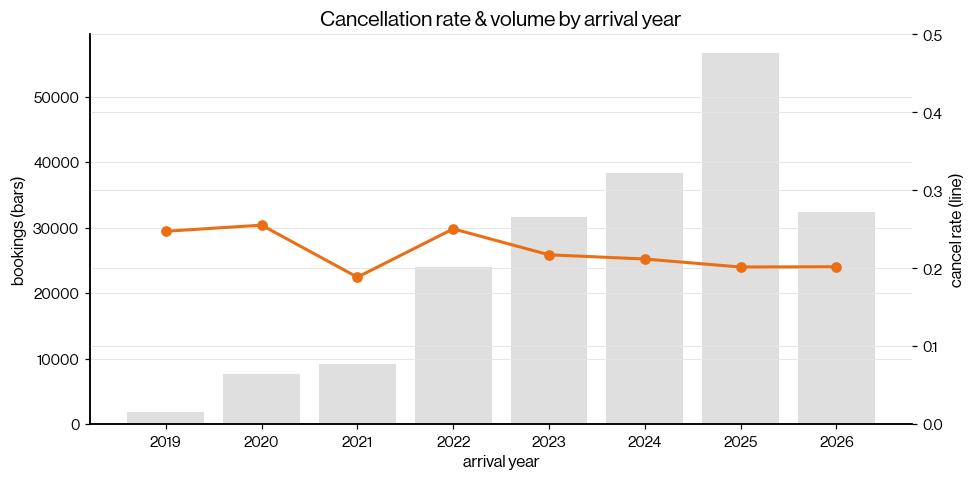

In [2]:
CUTOFF = pd.Timestamp.now("UTC").normalize() - pd.Timedelta(days=3)
FLOOR  = pd.Timestamp("2022-08-01", tz="UTC")   # chosen training floor (shown as a line)
resolved = df[df["status"].isin(["Canceled", "CheckedOut"])].copy()
# Drop FUTURE arrivals: their CheckedOut sibling stays haven't happened yet
# (still 'Confirmed'), so future months would show a spurious ~100% cancel rate.
resolved = resolved[resolved["arrival"] < CUTOFF].copy()
resolved["y"] = (resolved["status"] == "Canceled").astype(int)
resolved["arr_year"]  = resolved["arrival"].dt.year
resolved["arr_month"] = resolved["arrival"].dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()

g = (resolved.groupby("arr_year")
     .agg(n=("y", "size"), cancel_rate=("y", "mean")).reset_index())
print(g.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax2 = ax1.twinx()
ax1.bar(g["arr_year"], g["n"], alpha=0.25, color="grey")
ax2.plot(g["arr_year"], g["cancel_rate"], marker="o", color="C3", lw=2)
ax1.set_ylabel("bookings (bars)"); ax2.set_ylabel("cancel rate (line)")
ax2.set_ylim(0, max(0.5, g["cancel_rate"].max() * 1.15))
ax1.set_xlabel("arrival year"); ax1.set_title("Cancellation rate & volume by arrival year")
fig.tight_layout(); fig.savefig(OUT / "cancel_rate_by_year.png", dpi=130, bbox_inches="tight")
plt.show()

## 2 - Cancel rate by arrival Month

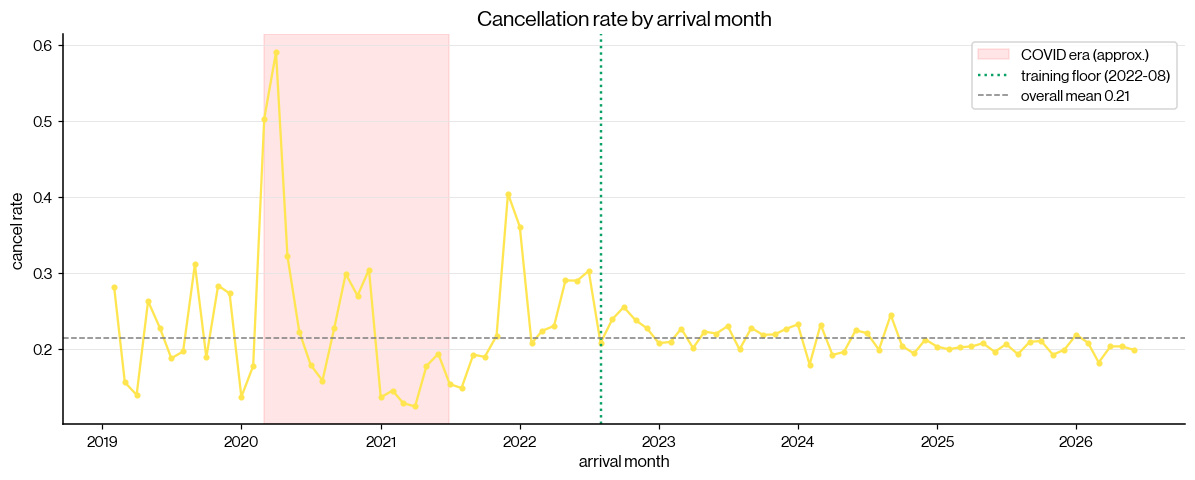

In [3]:
gm = (resolved.groupby("arr_month")
      .agg(n=("y", "size"), cancel_rate=("y", "mean")).reset_index())
gm = gm[gm["n"] >= 50]   # suppress noisy low-volume months

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(gm["arr_month"], gm["cancel_rate"], marker=".", lw=1.5)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"),
           color="red", alpha=0.10, label="COVID era (approx.)")
ax.axvline(pd.Timestamp("2022-08-01"), color="C2", ls=":", lw=1.6,
           label="training floor (2022-08)")
ax.axhline(resolved["y"].mean(), color="grey", ls="--", lw=1,
           label=f"overall mean {resolved['y'].mean():.2f}")
ax.set_xlabel("arrival month"); ax.set_ylabel("cancel rate")
ax.set_title("Cancellation rate by arrival month"); ax.legend()
fig.tight_layout(); fig.savefig(OUT / "cancel_rate_by_month.png", dpi=130, bbox_inches="tight")
plt.show()

## 3 - Cancel rate by lead-time bucket, pre-2022 vs 2022+

era          <=2021 (incl. COVID)  >=2022
lead_bucket                              
0-7d                        0.110   0.134
8-30d                       0.258   0.219
31-90d                      0.515   0.306
90d+                        0.764   0.427


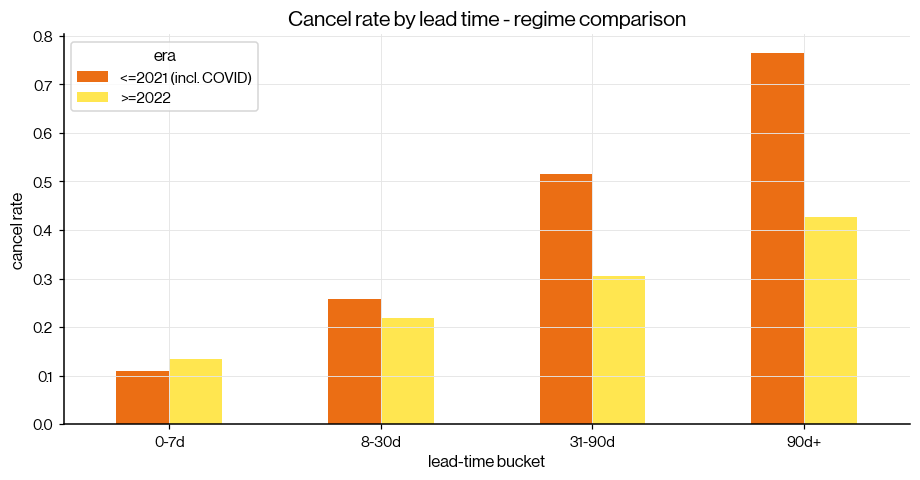

In [4]:
r = resolved.copy()
r["lead_days"] = ((r["arrival"].dt.normalize() - r["created"].dt.normalize())
                  / pd.Timedelta(days=1)).clip(lower=0)
r["lead_bucket"] = pd.cut(r["lead_days"], bins=[-1, 7, 30, 90, 10_000],
                          labels=["0-7d", "8-30d", "31-90d", "90d+"])
r["era"] = np.where(r["arr_year"] <= 2021, "<=2021 (incl. COVID)", ">=2022")
piv = (r.groupby(["lead_bucket", "era"])["y"].mean().unstack())
print(piv.to_string(float_format=lambda v: f"{v:.3f}"))

ax = piv.plot(kind="bar", figsize=(8.5, 4.5), color=["C3", "C0"])
ax.set_ylabel("cancel rate"); ax.set_xlabel("lead-time bucket")
ax.set_title("Cancel rate by lead time - regime comparison")
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(OUT / "cancel_rate_by_leadtime_era.png", dpi=130, bbox_inches="tight")
plt.show()

## 4 - Status-resolution latency

For bookings whose arrival is near the data snapshot, what fraction is still `Confirmed` as a function of days since arrival? Where the curve hits ~0, labels have resolved - that is the minimum safe grace window.

snapshot asof = 2026-06-09
 days_since_arrival  frac_confirmed   n
             -2.000           0.853 217
             -1.000           0.833 234
              0.000           0.812 293
              1.000           0.010 406
              2.000           0.017 179
              3.000           0.000 209
              4.000           0.000 291
              5.000           0.000 198
              6.000           0.000 142
              7.000           0.000 202
              8.000           0.000 360
              9.000           0.000 178
             10.000           0.000 253
             11.000           0.000 310
             12.000           0.000 155
             13.000           0.000 208
             14.000           0.000 322
             15.000           0.000 143
             16.000           0.000 100
             17.000           0.000 305
             18.000           0.000 284
             19.000           0.000 208
             20.000           0.000 252
             

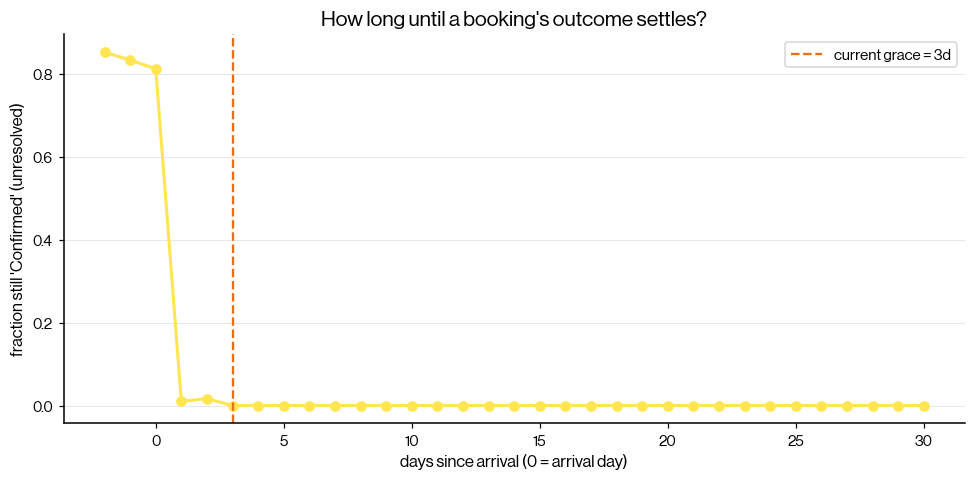

In [5]:
asof = df["created"].max()           # snapshot proxy (latest write we have)
d = df.copy()
d["days_since_arrival"] = ((asof.normalize() - d["arrival"].dt.normalize())
                           / pd.Timedelta(days=1))
recent = d[(d["days_since_arrival"] >= -2) & (d["days_since_arrival"] <= 30)]
lat = (recent.assign(is_confirmed=(recent["status"] == "Confirmed").astype(int))
       .groupby("days_since_arrival")
       .agg(frac_confirmed=("is_confirmed", "mean"), n=("is_confirmed", "size"))
       .reset_index())
print(f"snapshot asof = {asof.date()}")
print(lat.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(lat["days_since_arrival"], lat["frac_confirmed"], marker="o")
ax.axvline(3, color="C3", ls="--", lw=1.5, label="current grace = 3d")
ax.set_xlabel("days since arrival (0 = arrival day)")
ax.set_ylabel("fraction still 'Confirmed' (unresolved)")
ax.set_title("How long until a booking's outcome settles?"); ax.legend()
fig.tight_layout(); fig.savefig(OUT / "status_resolution_latency.png", dpi=130, bbox_inches="tight")
plt.show()